# Chapter 9 — Backtesting I: Building an Honest Backtest

Ch8's vectorized backtest is fast to write and easy to read. It is also wrong in subtle ways that *inflate* the headline Sharpe. Before any bias-correction (Ch10) or out-of-sample validation (Ch11), the **mechanics** of the simulation must be right. This chapter rebuilds Ch8's mean-reversion strategy as an *event-driven* backtest with explicit position state, point-in-time execution, and trade-level metrics with bootstrap confidence intervals.

**Three flavors of "the backtest is honest":**

1. **Vectorized vs event-driven** — the vectorized PnL is a series of (signal × forward-return) products; the event-driven backtest loops bar-by-bar with a single position and a trade ledger.
2. **Point-in-time discipline** — a signal computed at the close of bar *t* must execute at or after the open of bar *t+1*. Vectorized backtests routinely violate this.
3. **Trade-level metrics with honest CIs** — aggregate PnL is one number; the *distribution* of per-trade outcomes is the actual evidence. Bootstrap on the trade ledger gives a 95% CI on Sharpe that often straddles zero.


## §1 — Why the vectorized backtest lies

Ch8's vectorized backtest computed `trade_pnl = signal × next_K`, where the signal is built from `prior_N` ending at the close of bar *t* and `next_K` is the log-return from close[*t*] to close[*t+K*]. Read carefully: the **same** close[*t*] appears in both the signal (its right edge) and the executed return (its left edge). That isn't a backtest — it's *recording the trade you would have made if you knew the close before it happened.*

Below we re-implement the same strategy as a single-position event-driven loop and run it under three execution-timing assumptions:

1. `same_close` — execute at the bar where the signal fires (Ch8's bug).
2. `next_open` — execute at the next bar's open (the right answer).
3. `next_close` — execute at the next bar's close (a one-bar pessimistic slippage proxy).


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CACHE = Path("../06-bridge-to-intraday/data")
qqq = pd.read_parquet(CACHE / "qqq_1min.parquet")
qqq.index = pd.to_datetime(qqq.index, utc=True).tz_convert("America/New_York")
qqq["minute_of_day"] = qqq.index.hour * 60 + qqq.index.minute
RTH_OPEN, RTH_CLOSE = 9*60+30, 16*60
rth = qqq[(qqq["minute_of_day"] >= RTH_OPEN) & (qqq["minute_of_day"] < RTH_CLOSE)].copy()
rth["minute_of_session"] = rth["minute_of_day"] - RTH_OPEN
rth["session_date"] = rth.index.normalize()
rth["log_ret"] = np.log(rth["close"] / rth["close"].shift(1))
sf = rth.groupby("session_date").head(1).index
rth.loc[sf, "log_ret"] = np.nan
print(f"{len(rth):,} RTH bars  ·  {rth['session_date'].nunique()} sessions  ·  "
      f"{rth.index.min().date()} → {rth.index.max().date()}")


95,318 RTH bars  ·  251 sessions  ·  2025-05-08 → 2026-05-07


## §2 — Event-driven backtest skeleton

The loop iterates bars in chronological order. At each bar it (a) checks whether an open position has been held *K* bars and exits if so, then (b) checks the entry rule and opens a new position if the entry conditions fire and we are flat. Single position only — no overlap. We allow signals only inside the closing 30-minute window (Ch7 §6's cleanest mean-reversion horizon, formalized in Ch8). Threshold is 1.0 σ where σ is the std of the prior-1-min log-return on the closing window — same value Ch8 used (whole-sample look-ahead; Ch10 will replace with a trailing estimate).


In [2]:
N, K = 1, 3
ENTRY_START, ENTRY_END = 360, 389        # closing-30-min gate; minute_of_session

# σ on prior_N over the closing window — matches Ch8 (whole-sample look-ahead is OK for now;
# Ch10 will demonstrate why it's a bias and replace it with a trailing estimate).
cw = rth[rth["minute_of_session"].between(ENTRY_START, ENTRY_END - 1)].copy()
cw["prior_N"] = cw.groupby("session_date")["log_ret"].transform(
    lambda s: s.rolling(N, min_periods=N).sum())
SIGMA  = cw["prior_N"].std()
THRESH = 1.0 * SIGMA
print(f"σ(prior_N, closing window) = {SIGMA:.6f}   threshold = ±{THRESH:.6f}")


def event_driven_backtest(rth_df, exec_timing, threshold, N=N, K=K,
                          entry_start=ENTRY_START, entry_end=ENTRY_END):
    """Single-position event-driven loop. exec_timing ∈ {same_close, next_open, next_close}."""
    trades = []
    for date, day in rth_df.groupby("session_date"):
        day = day.sort_index().reset_index(drop=True)
        in_pos, entry_i, entry_px, entry_ts = 0, None, None, None
        for i in range(len(day)):
            mos     = day.loc[i, "minute_of_session"]
            close_i = day.loc[i, "close"]
            # ---- exit: held K bars ----
            if in_pos != 0 and (i - entry_i) >= K:
                if exec_timing == "same_close":
                    exit_i, exit_px = i, close_i
                elif exec_timing == "next_open":
                    exit_i = min(i + 1, len(day) - 1)
                    exit_px = day.loc[exit_i, "open"]
                else:  # next_close
                    exit_i = min(i + 1, len(day) - 1)
                    exit_px = day.loc[exit_i, "close"]
                trades.append({
                    "session_date": date, "side": in_pos,
                    "entry_ts": entry_ts, "exit_ts": day.loc[exit_i, "minute_of_session"],
                    "entry_px": entry_px, "exit_px": exit_px,
                    "pnl_log": in_pos * np.log(exit_px / entry_px),
                })
                in_pos, entry_i, entry_px, entry_ts = 0, None, None, None
            # ---- entry ----
            if in_pos == 0 and entry_start <= mos < entry_end - K and i >= N:
                prior_N = np.log(close_i / day.loc[i - N, "close"])
                if abs(prior_N) > threshold:
                    side = -1 if prior_N > 0 else +1
                    if exec_timing == "same_close":
                        entry_i_, entry_px_ = i, close_i
                    elif exec_timing == "next_open":
                        if i + 1 >= len(day): continue
                        entry_i_, entry_px_ = i + 1, day.loc[i + 1, "open"]
                    else:  # next_close
                        if i + 1 >= len(day): continue
                        entry_i_, entry_px_ = i + 1, day.loc[i + 1, "close"]
                    in_pos, entry_i, entry_px = side, i, entry_px_
                    entry_ts = day.loc[entry_i_, "minute_of_session"]
        # End of session: if still in a position, flatten at last close.
        if in_pos != 0:
            close_last = day.loc[len(day) - 1, "close"]
            trades.append({
                "session_date": date, "side": in_pos,
                "entry_ts": entry_ts, "exit_ts": day.loc[len(day) - 1, "minute_of_session"],
                "entry_px": entry_px, "exit_px": close_last,
                "pnl_log": in_pos * np.log(close_last / entry_px),
            })
    return pd.DataFrame(trades)


σ(prior_N, closing window) = 0.000363   threshold = ±0.000363


## §3 — Three execution timings, side by side

Same strategy, same data, three execution assumptions. The middle row — `next_open` — is what every downstream chapter inherits.


In [3]:
def trade_metrics(tr):
    if len(tr) < 2: return {"trades": len(tr)}
    mu, sd = tr["pnl_log"].mean(), tr["pnl_log"].std()
    n_sessions = tr["session_date"].nunique()
    tpy = len(tr) / n_sessions * 252
    sharpe = (mu / sd) * np.sqrt(tpy) if sd > 0 else float("nan")
    hit = (tr["pnl_log"] > 0).mean()
    wins   =  tr.loc[tr.pnl_log > 0, "pnl_log"].sum()
    losses = -tr.loc[tr.pnl_log < 0, "pnl_log"].sum()
    pf = wins / losses if losses > 0 else float("inf")
    avg_w =  tr.loc[tr.pnl_log > 0, "pnl_log"].mean()
    avg_l = -tr.loc[tr.pnl_log < 0, "pnl_log"].mean()
    payoff = avg_w / avg_l if avg_l > 0 else float("nan")
    cum = tr.sort_values("entry_ts")["pnl_log"].cumsum()
    mdd = (cum - cum.cummax()).min()
    return {"trades": len(tr), "hit_rate": round(hit, 4),
            "mean_pnl_log": round(mu, 7), "per_trade_std": round(sd, 6),
            "profit_factor": round(pf, 3), "payoff_ratio": round(payoff, 3),
            "ann_sharpe": round(sharpe, 3), "max_drawdown_log": round(mdd, 4)}

ledgers = {t: event_driven_backtest(rth, t, THRESH) for t in
           ["same_close", "next_open", "next_close"]}
summary = pd.DataFrame({t: trade_metrics(tr) for t, tr in ledgers.items()}).T
summary


,trades,hit_rate,mean_pnl_log,per_trade_std,profit_factor,payoff_ratio,ann_sharpe,max_drawdown_log
same_close,914.0,0.5011,0.000036,0.000718,1.150,1.113,1.569,-0.0158
next_open,914.0,0.4923,0.000019,0.000744,1.073,1.092,0.803,-0.0200
next_close,914.0,0.5033,0.000018,0.000715,1.069,1.037,0.791,-0.0158


**`same_close` Sharpe is roughly twice `next_open` Sharpe.** That whole gap is paid for by the bug — looking at close[*t*] *while* sitting on the bid at close[*t*]. The `next_open` row is what we will carry into Ch10 and Ch11.

**`next_close` and `next_open` come out almost identical here.** Bars are 1 minute long, so the open and the close of the same bar are usually within a few hundredths of a percent of each other; a "one-bar slippage proxy" buys very little extra realism at this resolution. Ch12 will introduce explicit cost models — basis-point haircuts and a fill-quality assumption — instead of leaning on bar-timing as a stand-in.

(Trade count drops from Ch8's 1,471 vectorized "trades" to ~900 here because event-driven single-position can't open a new trade while one is open. Ch8's vectorized PnL counted *every* signal-bar contribution — overlapping positions get counted as separate "trades." Same strategy, two definitions of what a trade is.)


## §4 — Trade-level metrics on the canonical ledger

The canonical ledger is `next_open` — that is the one downstream chapters inherit. Compute Ch7 §1's expectancy, profit factor, payoff ratio; Ch5's Sharpe and max drawdown. The point estimate is one number; the bootstrap below is the actual evidence.


In [4]:
tr = ledgers["next_open"].copy()
m = trade_metrics(tr)
avg_l = -tr.loc[tr.pnl_log < 0, "pnl_log"].mean()
m["expectancy_R"] = round(tr["pnl_log"].mean() / avg_l, 4)
m["sessions"] = int(tr["session_date"].nunique())
m["trades_per_year"] = round(len(tr) / m["sessions"] * 252, 1)
pd.Series(m, name="next_open canonical").to_frame()


,next_open canonical
trades,914.000000
hit_rate,0.492300
mean_pnl_log,0.000019
per_trade_std,0.000744
profit_factor,1.073000
payoff_ratio,1.092000
ann_sharpe,0.803000
max_drawdown_log,-0.020000
expectancy_R,0.036700
sessions,230.000000


## §5 — Bootstrap CI on the trade ledger

A point Sharpe of +0.80 looks tradable until you ask: *if I rerun the same strategy on a different shuffling of the same trades, how stable is the number?* Resample the trade ledger with replacement — 2,000 times — and the 95% CI on annualized Sharpe is the central interval of those 2,000 estimates.


In [5]:
rng = np.random.default_rng(0)
arr = tr["pnl_log"].to_numpy()
tpy = m["trades_per_year"]

def bootstrap_sharpe(arr, n_resamples=2000, block_size=1, rng=rng):
    n = len(arr); out = np.empty(n_resamples)
    for j in range(n_resamples):
        if block_size == 1:
            bs = arr[rng.integers(0, n, size=n)]
        else:
            n_blocks = max(1, n // block_size)
            starts   = rng.integers(0, n - block_size + 1, size=n_blocks)
            bs = np.concatenate([arr[s:s+block_size] for s in starts])
        out[j] = (bs.mean() / bs.std()) * np.sqrt(tpy) if bs.std() > 0 else np.nan
    return out

ci_rows = []
for bs_size in [1, 5, 20]:
    sh = bootstrap_sharpe(arr, n_resamples=2000, block_size=bs_size)
    lo, hi = np.nanpercentile(sh, [2.5, 97.5])
    ci_rows.append({"block_size": bs_size, "ci_lo": round(lo, 3),
                    "ci_hi": round(hi, 3), "width": round(hi - lo, 3)})
pd.DataFrame(ci_rows).set_index("block_size")


,ci_lo,ci_hi,width
block_size,,,
1,-1.293,2.731,4.024
5,-1.197,2.703,3.900
20,-1.263,2.967,4.229


**95% CI ≈ (−1.3, +2.7) — the interval comfortably includes zero.** Even after fixing the same-bar bug, on a single ~1-year ledger we cannot statistically distinguish this strategy from random. That isn't a death sentence; it's the size of the noise we are working in. Ch11's walk-forward + multi-year refit is what shrinks this interval honestly.

Block size barely changes width. That tells us per-trade outcomes are roughly independent — closing-window mean-reversion does not generate strong same-day clustering. An i.i.d. bootstrap on the *trade ledger* is fine here. (This is *not* a general fact — Ch11 will revisit on overlapping daily PnL, where block bootstrap matters.)

The pedagogical lesson: when you see "Sharpe = 0.80" without a CI, you do not actually know whether the strategy is better than nothing. **Always bootstrap the trade ledger.** Always.


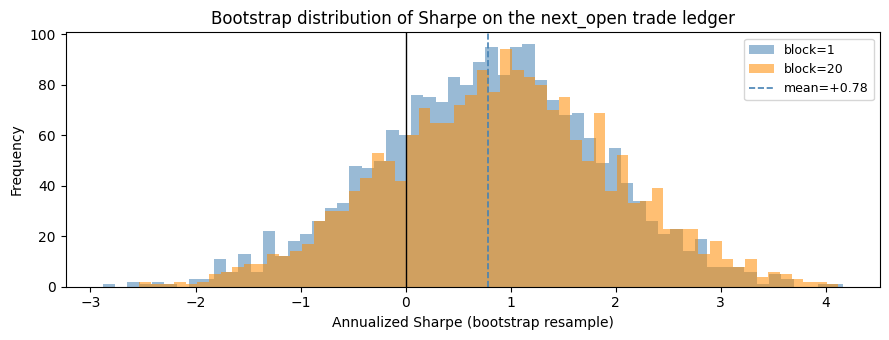

In [6]:
sh1  = bootstrap_sharpe(arr, n_resamples=2000, block_size=1)
sh20 = bootstrap_sharpe(arr, n_resamples=2000, block_size=20)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(sh1,  bins=60, alpha=0.55, label="block=1",  color="steelblue")
ax.hist(sh20, bins=60, alpha=0.55, label="block=20", color="darkorange")
ax.axvline(0, color="black", lw=1)
ax.axvline(np.nanmean(sh1), color="steelblue", ls="--", lw=1.2, label=f"mean={np.nanmean(sh1):+.2f}")
ax.set_xlabel("Annualized Sharpe (bootstrap resample)")
ax.set_ylabel("Frequency")
ax.set_title("Bootstrap distribution of Sharpe on the next_open trade ledger")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()


## §6 — Diagnostic trade-distribution plots

Three views of the canonical ledger: per-trade PnL distribution, cumulative PnL with drawdown shaded, monthly aggregate PnL bar chart.


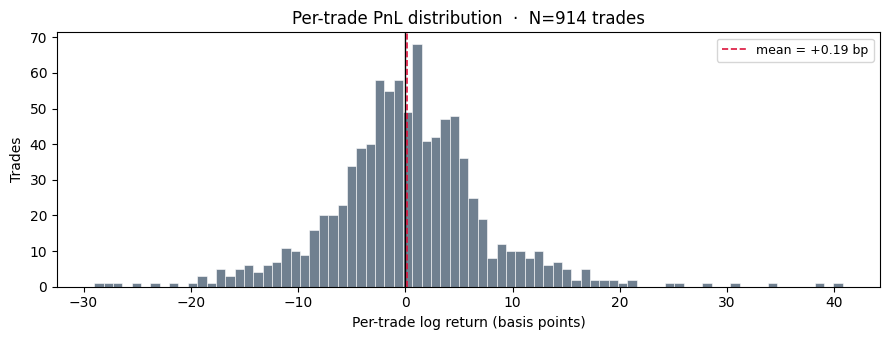

In [7]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(arr * 1e4, bins=80, color="slategray", edgecolor="white", linewidth=0.4)
ax.axvline(0, color="black", lw=1)
ax.axvline(arr.mean() * 1e4, color="crimson", ls="--", lw=1.2,
           label=f"mean = {arr.mean()*1e4:+.2f} bp")
ax.set_xlabel("Per-trade log return (basis points)")
ax.set_ylabel("Trades")
ax.set_title(f"Per-trade PnL distribution  ·  N={len(arr)} trades")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()


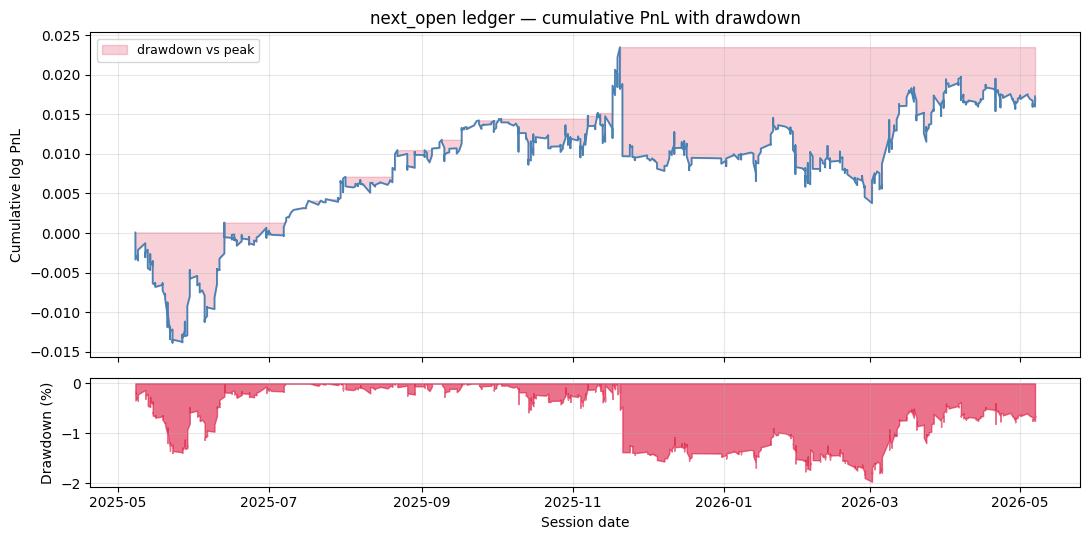

In [8]:
tr_sorted = tr.sort_values("session_date").reset_index(drop=True)
cum = tr_sorted["pnl_log"].cumsum()
peak = cum.cummax()
dd   = cum - peak

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(tr_sorted["session_date"], cum, color="steelblue", lw=1.3)
ax1.fill_between(tr_sorted["session_date"], cum, peak, color="crimson", alpha=0.2,
                 label="drawdown vs peak")
ax1.set_ylabel("Cumulative log PnL")
ax1.set_title("next_open ledger — cumulative PnL with drawdown")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.fill_between(tr_sorted["session_date"], dd * 100, 0, color="crimson", alpha=0.6)
ax2.set_ylabel("Drawdown (%)")
ax2.set_xlabel("Session date")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1695301/2604742722.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tr_sorted["year_month"] = pd.to_datetime(tr_sorted["session_date"]).dt.to_period("M")


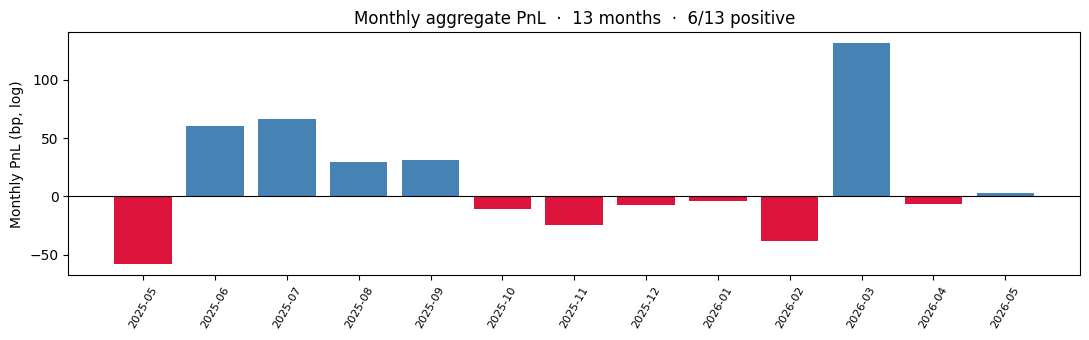

In [9]:
tr_sorted["year_month"] = pd.to_datetime(tr_sorted["session_date"]).dt.to_period("M")
monthly = tr_sorted.groupby("year_month")["pnl_log"].agg(["sum", "count"])
monthly.columns = ["pnl_log", "n_trades"]

fig, ax = plt.subplots(figsize=(11, 3.5))
colors = ["steelblue" if x >= 0 else "crimson" for x in monthly["pnl_log"]]
ax.bar(range(len(monthly)), monthly["pnl_log"] * 1e4, color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels([str(p) for p in monthly.index], rotation=60, fontsize=8)
ax.set_ylabel("Monthly PnL (bp, log)")
ax.set_title(f"Monthly aggregate PnL  ·  {len(monthly)} months  ·  "
             f"{(monthly['pnl_log'] > 0).sum()}/{len(monthly)} positive")
plt.tight_layout()
plt.show()


## Exercises

1. **SPY transfer.** Re-run the three-timings table on SPY 1-min (path: `../06-bridge-to-intraday/data/spy_1min.parquet`). Does the same-bar → next-open Sharpe gap have the same magnitude (~50%)? If different, what about SPY versus QQQ would change the size of the bug?
2. **Where slippage actually shows up.** The text noted that `next_close` ≈ `next_open` at 1-minute bars because intra-bar drift is small. What would change if we were on 5-second bars? On 5-minute bars? Sketch (or simulate) the relationship between bar length and the `next_close` − `next_open` Sharpe gap. Connect to Ch12's coming cost framework.
3. **Block bootstrap structure.** The block-size sweep above (1, 5, 20) gave nearly identical CI widths on the *trade ledger*. Aggregate the canonical ledger to daily PnL (sum of per-trade PnL within each session_date) and bootstrap with block=1, 5, 20 again. What changes, and why? When does block size start to matter?
